# 09 · Paradigm competition under entrenched Newtonian priors

**The Kuhnian empirical-superiority story.** Kuhn argued that paradigm
shifts happen when accumulated evidence is better explained by a new
model than by the old one. This notebook formalises that story:

- The world is generated by an unknown θ\* ∈ ℝ^K. Two competing
  hypotheses, M_N (Newtonian) and M_R (Relativistic), each predict a
  specific θ value. They disagree across all four dimensions with
  varying magnitudes — every community can in principle distinguish
  N from R, but at very different speeds depending on which
  dimension they probe.

- **Everyone starts as a Newtonian.** Initial belief is concentrated on
  μ(0) = θ_N with sharp precision Λ(0) = λ₀ · I — i.e., the population
  enters with strong commitment to the traditional model. There are no
  "free-thinking factions" baked in: the minority that emerges does so
  *endogenously* through the discriminating evidence its experiments
  happen to collect.

- **The truth is Relativistic.** θ\*(t) = θ_R for all t. There is no
  shock, no reversal — this is the "Mercury's perihelion accumulates"
  story, not the "the world suddenly changed" story.

- **The empirical observable is the log Bayes factor.** For each agent,

  $$ \log\!\frac{p(M_R \mid \text{data})}{p(M_N \mid \text{data})}
    = \tfrac{1}{2}(\theta_N - \mu)^\top \Lambda (\theta_N - \mu)
    - \tfrac{1}{2}(\theta_R - \mu)^\top \Lambda (\theta_R - \mu). $$

  This is the standard point-Bayes factor between two hypotheses under
  a Gaussian posterior. It starts at 0 (uniform model prior, μ = θ_N
  by construction so the quadratic forms cancel for d_N but not d_R —
  see §1 for the explicit pre-shock value) and climbs as evidence
  accumulates against M_N.

- **The four communities are the four "attentional regimes" from
  notebook 08.** Each probes one peak of the Gaussian-bump basis,
  collecting evidence sensitive to one component of θ. Communities
  whose `Δθ_k = θ_R[k] − θ_N[k]` is large discover R quickly;
  communities whose Δθ_k is small need many more observations *or*
  must trust the early discoverers.

**The headline figure is the per-community log Bayes factor over time.**
It answers, in one chart: *who switches paradigm, when, and what role
does inter-community trust play?*

This notebook reuses the multivariate-Gaussian inference machinery from
notebook 08 verbatim (copied, not imported — see §2 header). If 09's
findings warrant paper inclusion, those helpers will be promoted to
`src/world.py` and `src/inference.py` in a follow-up plan.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import seaborn as sns

from src.network import build_adjacency

sns.set_theme(context='notebook', style='whitegrid')
print('imports ok')

imports ok


## §1 · The two hypotheses and the predicted rate of discovery

Define the two competing parameter vectors. The Newtonian model predicts
modest, equal magnitudes across the first three dimensions and zero on
the fourth (no time-dilation-like effect). The Relativistic model
agrees broadly on the kind of phenomenon at each dimension but predicts
larger magnitudes — the disagreement grows as you move to higher-energy
/ more-extreme regimes.

| dim | $\theta_N$ | $\theta_R$ | $\Delta\theta$ | physical regime |
|---|---|---|---|---|
| 1 | 0.5 | 1.0 | 0.5 | low velocity / classical |
| 2 | 0.5 | 1.5 | 1.0 | mid-energy mechanics |
| 3 | 0.5 | 2.0 | 1.5 | high velocity / Lorentz |
| 4 | 0.0 | 2.5 | 2.5 | atomic-clock / time-dilation |

**Predicted discovery rate.** Under truth θ\* = θ_R, the per-observation
expected contribution to the log Bayes factor (R over N) for an agent
probing peak k with $h_k(x_k) \approx 1$ is

$$ \mathbb{E}[\Delta \log \mathrm{BF}] \approx \frac{(\Delta\theta_k)^2}{2\sigma^2}. $$

With σ = 0.5 the per-step rates are (1, 4, 9, 25) for communities
1–4. So C4 should reach the decisive-evidence threshold (log BF ≥ +10)
in ~2 steps of *its own* evidence — long before any social pooling
matters. C1 needs ~50 steps. The differential rate is the engine of the
whole story.

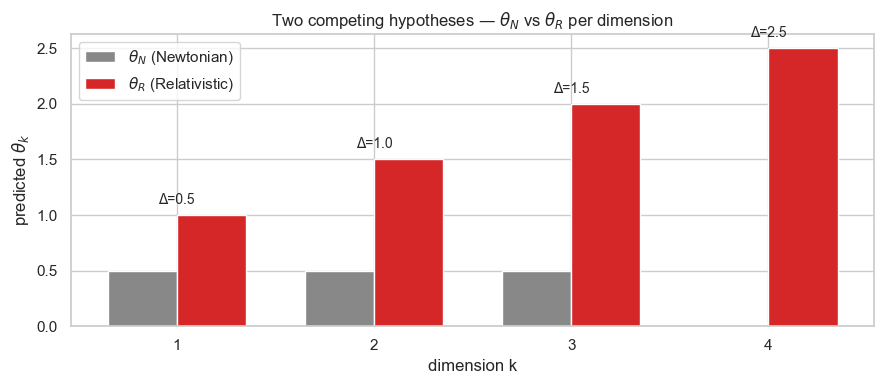

Predicted discovery times (steps to log BF >= +10, σ = 0.5, own evidence only):
                  Δθ_k    expected rate (log-BF/step)    expected steps
  Community 1:   0.50              0.50                   20.00
  Community 2:   1.00              2.00                    5.00
  Community 3:   1.50              4.50                    2.22
  Community 4:   2.50             12.50                    0.80


In [2]:
K = 4
theta_N = jnp.array([0.5, 0.5, 0.5, 0.0])
theta_R = jnp.array([1.0, 1.5, 2.0, 2.5])
delta_theta = theta_R - theta_N

LOGBF_THRESHOLD = 10.0       # Kass & Raftery (1995) "decisive" evidence
sigma_default = 0.5


def predicted_discovery_time(delta_k, sigma, threshold=LOGBF_THRESHOLD):
    """Expected per-community steps to log BF >= threshold, assuming
    h_k(x_k)=1 and the agent updates purely on its own observations.
    Closed form: t* = 2 sigma^2 * threshold / delta_k^2."""
    return 2.0 * (sigma ** 2) * threshold / max(delta_k ** 2, 1e-12)


fig, ax = plt.subplots(figsize=(9, 4))
palette = sns.color_palette('tab10', K)
dims = np.arange(1, K + 1)
width = 0.35
ax.bar(dims - width / 2, np.asarray(theta_N), width=width,
       color='#888', label=r'$\theta_N$ (Newtonian)')
ax.bar(dims + width / 2, np.asarray(theta_R), width=width,
       color='#d62728', label=r'$\theta_R$ (Relativistic)')
for k in range(K):
    ax.annotate(f'Δ={float(delta_theta[k]):.1f}',
                xy=(k + 1, max(float(theta_N[k]), float(theta_R[k])) + 0.1),
                ha='center', fontsize=10)
ax.set(xticks=dims, xlabel='dimension k', ylabel='predicted $\\theta_k$',
       title=r'Two competing hypotheses — $\theta_N$ vs $\theta_R$ per dimension')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

print('Predicted discovery times (steps to log BF >= +10, σ = 0.5, own evidence only):')
print('                  Δθ_k    expected rate (log-BF/step)    expected steps')
for k in range(K):
    dk = float(delta_theta[k])
    rate = dk ** 2 / (2 * sigma_default ** 2)
    steps = predicted_discovery_time(dk, sigma_default)
    print(f'  Community {k+1}:   {dk:.2f}            {rate:>6.2f}                  {steps:>6.2f}')

## §2 · Vector inference helpers — *copied from notebook 08*

The basis (`h_basis`, `h0`, `sample_o`) and multivariate-Gaussian
machinery (`private_update_vec`, `precision_pool_vec`,
`log_predictive_vec`, `surprisal_matrix_vec`) below are **lifted verbatim
from notebook 08**. They live there as notebook-local code; if either
notebook becomes paper-load-bearing we'll promote them to `src/world.py`
and `src/inference.py` in a follow-up plan. For now: duplication is
cheaper than premature abstraction.

In [3]:
# --- Basis + world (from notebook 08 cell 78068cda) ---
x_peaks = jnp.array([1.0, 3.0, 5.0, 7.0])
basis_w = 0.6
sigma = sigma_default

def school_x_grid(k, n_pts=3, spread=0.4):
    centre = float(x_peaks[k])
    return tuple(np.linspace(centre - spread, centre + spread, n_pts).tolist())

SCHOOL_GRIDS = [school_x_grid(k) for k in range(K)]

def h_basis(x):
    x_ = jnp.asarray(x)[..., None]
    return jnp.exp(-((x_ - x_peaks) ** 2) / (basis_w ** 2))

def h0(x):
    return jnp.zeros_like(jnp.asarray(x))

def sample_o(x, theta_star, key):
    mean = h0(x) + h_basis(x) @ theta_star
    noise = jax.random.normal(key, jnp.shape(x)) * sigma
    return mean + noise


# --- Multivariate Gaussian inference (from notebook 08 cell a1b95af1) ---
EPS = 1e-9

def private_update_vec(mu, Lambda, x, o):
    h = h_basis(x)                               # (N, K)
    sigma2 = sigma ** 2
    HHT = h[:, :, None] * h[:, None, :] / sigma2
    Lambda_new = Lambda + HHT
    Lmu = jnp.einsum('nij,nj->ni', Lambda, mu)
    info = h * ((o - h0(x))[:, None]) / sigma2
    rhs = Lmu + info
    mu_new = jax.vmap(jnp.linalg.solve)(
        Lambda_new + EPS * jnp.eye(K)[None], rhs
    )
    return mu_new, Lambda_new

def precision_pool_vec(mu_priv, Lambda_priv, gamma, mask):
    weights = gamma * mask
    row_sum = weights.sum(axis=1, keepdims=True) + EPS
    w = weights / row_sum
    Lambda_pool = jnp.einsum('ij,jkl->ikl', w, Lambda_priv)
    Lmu_priv = jnp.einsum('jkl,jl->jk', Lambda_priv, mu_priv)
    num = jnp.einsum('ij,jk->ik', w, Lmu_priv)
    mu_pool = jax.vmap(jnp.linalg.solve)(
        Lambda_pool + EPS * jnp.eye(K)[None], num
    )
    return mu_pool, Lambda_pool

def surprisal_matrix_vec(mu_priv, Lambda_priv, x_obs, o_obs, mask):
    h_i = h_basis(x_obs)
    def per_j_quadratic(Lambda_j):
        return jax.vmap(lambda h: jnp.linalg.solve(Lambda_j + EPS * jnp.eye(K), h))(h_i)
    Sigma_h = jax.vmap(per_j_quadratic)(Lambda_priv)
    quad = jnp.einsum('ik,jik->ij', h_i, Sigma_h)
    pred_mean = h0(x_obs)[:, None] + h_i @ mu_priv.T
    pred_var = sigma ** 2 + quad
    log_norm = -0.5 * jnp.log(2.0 * jnp.pi * pred_var)
    log_kern = -0.5 * (o_obs[:, None] - pred_mean) ** 2 / pred_var
    return (-(log_norm + log_kern)) * mask


print('inference helpers loaded (vector, copied from notebook 08)')

inference helpers loaded (vector, copied from notebook 08)


## §3 · Entrenched-Newtonian initialisation

Everyone starts at μ = θ_N with Λ = λ₀ · I. The λ₀ knob controls
*entrenchment*: how many observations it takes before a typical agent
will revise away from θ_N. At λ₀ = 30 (default) the prior weight on θ_N
is equivalent to ~30 hypothetical observations per dimension — strong
but not impossible to overcome.

The truth is θ\* = θ_R, fixed for all t. There is no shock and no
schedule. Population: 80 agents in a 4-block planted SBM (20 per
community), each block's agents using their school-specific x_grid.

In [4]:
N_PER_SCHOOL = 20
N = K * N_PER_SCHOOL                                 # 80
membership = np.repeat(np.arange(K, dtype=np.int32), N_PER_SCHOOL)
agent_x_grids = jnp.asarray(
    np.stack([SCHOOL_GRIDS[s] for s in membership]),
    dtype=jnp.float32,
)

TRUST_RHO = 1.0                                       # PDF §5(i) regime
TRUST_N0 = 1.0
TRUST_EPS0 = 1.0
COST_SLOPE = 0.5
BETA_EXP = 1.0

A_np = build_adjacency(
    n_agents=N, mean_degree=6, rewiring_p=0.1, seed=2,
    kind='planted_sbm', society_membership=membership,
    intra_prob=0.20, inter_prob=0.01,
)
A_adj = jnp.asarray(A_np)
A_self = A_adj + jnp.eye(N, dtype=A_adj.dtype)


def init_population_entrenched(theta_N, lambda_0, seed=0):
    """All agents start at μ = θ_N, Λ = λ₀·I. Trust at the uniform
    Gamma prior. Returns dict state."""
    mu = jnp.broadcast_to(theta_N, (N, K)).astype(jnp.float32)
    Lambda = (lambda_0 * jnp.eye(K))[None].repeat(N, axis=0).astype(jnp.float32)
    alpha = TRUST_N0 * A_self
    beta = TRUST_N0 * TRUST_EPS0 * A_self
    gamma_raw = (alpha / (beta + EPS)) * A_self
    rs = gamma_raw.sum(axis=1, keepdims=True) + EPS
    gamma = (gamma_raw / rs) * A_self
    return dict(mu=mu, Lambda=Lambda, alpha=alpha, beta=beta, gamma=gamma,
                key=jax.random.PRNGKey(seed))


print(f'N = {N} (4 communities × {N_PER_SCHOOL})')
print(f'SBM edges: {int((A_adj > 0).sum()) // 2}')
print(f'default entrenchment λ₀ = 30, trust ρ = {TRUST_RHO}')

N = 80 (4 communities × 20)
SBM edges: 168
default entrenchment λ₀ = 30, trust ρ = 1.0


## §4 · The Bayes factor, evaluated per agent

Given an agent with Gaussian posterior $q(\theta) = \mathcal{N}(\mu, \Lambda^{-1})$
and two point-hypotheses $M_N$: θ = θ_N, $M_R$: θ = θ_R, the
log Bayes factor (R over N) is the difference of negative-log-density
evaluations:

$$
\log\!\frac{p(M_R \mid \text{data})}{p(M_N \mid \text{data})}
  = \tfrac{1}{2}(\theta_N - \mu)^\top \Lambda (\theta_N - \mu)
  - \tfrac{1}{2}(\theta_R - \mu)^\top \Lambda (\theta_R - \mu).
$$

At init (μ = θ_N, Λ = λ₀I), the first quadratic is zero and the second
is $\tfrac{1}{2} \lambda_0 \|\Delta\theta\|^2$ — so the initial log BF
is *negative* and large in magnitude: agents start very confident in
M_N. The Bayesian dynamics then have to pull this back across zero and
on to +10 before any community "converts."

In [5]:
def log_bayes_factor(mu, Lambda, theta_N=theta_N, theta_R=theta_R):
    """Per-agent log BF (R over N). Shapes: mu (N, K), Lambda (N, K, K).
    Returns (N,) array of log p(M_R|data) - log p(M_N|data)."""
    d_N = mu - theta_N
    d_R = mu - theta_R
    q_N = jnp.einsum('ni,nij,nj->n', d_N, Lambda, d_N)
    q_R = jnp.einsum('ni,nij,nj->n', d_R, Lambda, d_R)
    return 0.5 * (q_N - q_R)


def community_log_bf(mu, Lambda, membership):
    """Mean log BF per community. Returns shape (K_communities,)."""
    lbf = log_bayes_factor(mu, Lambda)               # (N,)
    return jnp.stack([
        lbf[jnp.asarray(membership) == s].mean()
        for s in range(int(membership.max()) + 1)
    ])


# Sanity check at init: log BF should be -½ λ₀ ||Δθ||² (negative & big)
state0 = init_population_entrenched(theta_N, lambda_0=30.0)
init_lbf = float(log_bayes_factor(state0['mu'], state0['Lambda']).mean())
predicted_init_lbf = -0.5 * 30.0 * float(jnp.sum(delta_theta ** 2))
print(f'init log BF (mean across agents): {init_lbf:.3f}')
print(f'predicted -½ λ₀ ||Δθ||²:          {predicted_init_lbf:.3f}')
print(f'  → agents start STRONGLY favouring M_N (entrenchment doing its job)')

init log BF (mean across agents): -146.250
predicted -½ λ₀ ||Δθ||²:          -146.250
  → agents start STRONGLY favouring M_N (entrenchment doing its job)


## §5 · Rollout — fixed truth θ\* = θ_R

The step function is identical to notebook 08's `step_vec`. The only
difference: the world's truth schedule is *constant* at θ_R for all t.
T = 300 (longer than 08 — the entrenched prior takes time to overcome).

In [6]:
def expected_info_gain_vec(Lambda, x_grid):
    sign_old, logdet_old = jnp.linalg.slogdet(Lambda + EPS * jnp.eye(K)[None])
    h_grid = h_basis(x_grid)
    HHT = h_grid[..., :, None] * h_grid[..., None, :] / (sigma ** 2)
    Lambda_post = Lambda[:, None] + HHT
    sign_new, logdet_new = jnp.linalg.slogdet(
        Lambda_post + EPS * jnp.eye(K)[None, None]
    )
    return 0.5 * (logdet_new - logdet_old[:, None])


def choose_x(Lambda, x_grid, key):
    eig = expected_info_gain_vec(Lambda, x_grid)
    cost = COST_SLOPE * jnp.abs(x_grid)
    logits = BETA_EXP * (eig - cost)
    keys = jax.random.split(key, x_grid.shape[0])
    idx = jax.vmap(jax.random.categorical)(keys, logits)
    return jnp.take_along_axis(x_grid, idx[:, None], axis=1)[:, 0]


@jax.jit
def step_vec(state, theta_star):
    """One world-step. Truth θ* is passed in (fixed externally), so the
    same JIT compilation is reused across the entire rollout."""
    key_pol, key_obs, key_next = jax.random.split(state['key'], 3)
    x_chosen = choose_x(state['Lambda'], agent_x_grids, key_pol)
    o_obs = sample_o(x_chosen, theta_star, key_obs)
    mu_priv, Lambda_priv = private_update_vec(
        state['mu'], state['Lambda'], x_chosen, o_obs
    )
    mu_pool, Lambda_pool = precision_pool_vec(
        mu_priv, Lambda_priv, state['gamma'], A_self
    )
    epsilon = surprisal_matrix_vec(mu_priv, Lambda_priv, x_chosen, o_obs, A_self)
    alpha_new = TRUST_RHO * state['alpha'] + A_self
    beta_new = TRUST_RHO * state['beta'] + epsilon
    gamma_raw = (alpha_new / (beta_new + EPS)) * A_self
    rs = gamma_raw.sum(axis=1, keepdims=True) + EPS
    gamma_new = (gamma_raw / rs) * A_self
    new_state = dict(
        mu=mu_pool, Lambda=Lambda_pool,
        alpha=alpha_new, beta=beta_new, gamma=gamma_new,
        key=key_next,
    )
    return new_state, dict(x=x_chosen, o=o_obs)


def rollout(state, T=300, snap_every=4, theta_star=theta_R):
    snapshots = []
    log_bf_per_t = []                                # (T,) mean per-agent log BF
    log_bf_per_community = []                        # (T, K)
    for t in range(T):
        state, _ = step_vec(state, theta_star)
        lbf = log_bayes_factor(state['mu'], state['Lambda'])
        log_bf_per_t.append(float(lbf.mean()))
        log_bf_per_community.append(np.asarray(community_log_bf(
            state['mu'], state['Lambda'], membership)))
        if t % snap_every == 0:
            snapshots.append({
                'step': t,
                'mu': np.asarray(state['mu']),
                'Lambda': np.asarray(state['Lambda']),
                'alpha': np.asarray(state['alpha']),
                'beta': np.asarray(state['beta']),
            })
    return state, snapshots, np.asarray(log_bf_per_t), np.stack(log_bf_per_community)


# Main rollout, default entrenchment λ₀ = 30.
T = 300
state = init_population_entrenched(theta_N, lambda_0=30.0, seed=0)
state, snapshots, log_bf_mean, log_bf_comm = rollout(state, T=T, snap_every=4)
print(f'rollout done — T = {T}, {len(snapshots)} snapshots')
print(f'final per-community mean log BF (R over N):')
for s in range(K):
    print(f'  Community {s+1}: {log_bf_comm[-1, s]:+8.2f}')
print(f'final overall mean: {log_bf_mean[-1]:+8.2f}')

rollout done — T = 300, 75 snapshots
final per-community mean log BF (R over N):
  Community 1:  +792.87
  Community 2:  +757.30
  Community 3:  +790.95
  Community 4:  +858.86
final overall mean:  +800.00


## §6 · Headline — per-community log Bayes factor over time

The single figure that answers *who switches paradigm, when, and what
role does trust play?*. Read horizontally:

- A community's line climbs out of the entrenched-Newtonian basin
  (initially deep below zero) as evidence accumulates.
- Lines that cross **+10** have "decisively" converted to M_R
  (Kass & Raftery 1995).
- The ordering of crossings is the empirical claim: C4 first (strong
  Δθ), C3 next, then C2, then C1 — *if* each community were purely
  closed. The interesting case is when a slow-Δθ community converts
  *faster* than its own evidence would allow, courtesy of trust in a
  fast-Δθ community. Vertical dashed lines mark each community's
  observed crossing time; compare to the §1 predictions in the legend.

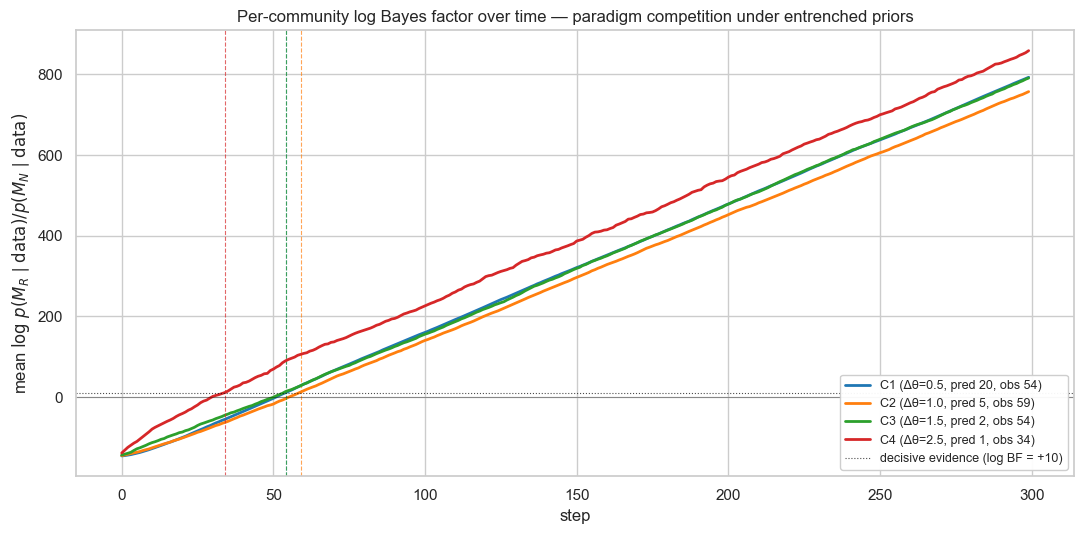

Observed time-to-conversion (mean log BF first crosses +10):
  Community 1: t = 54
  Community 2: t = 59
  Community 3: t = 54
  Community 4: t = 34


In [7]:
def time_to_conversion(log_bf_series, threshold=LOGBF_THRESHOLD):
    """First-crossing time for the threshold. None if never crossed."""
    over = np.where(log_bf_series >= threshold)[0]
    return int(over[0]) if over.size else None


fig, ax = plt.subplots(figsize=(11, 5.5))
T_axis = np.arange(T)
palette = sns.color_palette('tab10', K)

conv_times = []
for s in range(K):
    series = log_bf_comm[:, s]
    t_conv = time_to_conversion(series)
    conv_times.append(t_conv)
    dk = float(delta_theta[s])
    pred = predicted_discovery_time(dk, sigma)
    pred_str = f'pred {pred:.0f}'
    obs_str = f'obs {t_conv}' if t_conv is not None else 'obs ∞'
    label = f'C{s+1} (Δθ={dk:.1f}, {pred_str}, {obs_str})'
    ax.plot(T_axis, series, color=palette[s], lw=2.0, label=label)
    if t_conv is not None:
        ax.axvline(t_conv, color=palette[s], ls='--', lw=0.8, alpha=0.7)

ax.axhline(0.0, color='black', ls='-', lw=0.6, alpha=0.4)
ax.axhline(LOGBF_THRESHOLD, color='black', ls=':', lw=0.8, alpha=0.7,
           label=f'decisive evidence (log BF = +{LOGBF_THRESHOLD:.0f})')
ax.set(xlabel='step', ylabel=r'mean $\log\, p(M_R\mid \mathrm{data}) / p(M_N\mid \mathrm{data})$',
       title='Per-community log Bayes factor over time — paradigm competition under entrenched priors')
ax.legend(loc='lower right', fontsize=9, framealpha=0.95)
plt.tight_layout()
plt.show()

print('Observed time-to-conversion (mean log BF first crosses +10):')
for s in range(K):
    t_c = conv_times[s]
    print(f'  Community {s+1}: t = {t_c if t_c is not None else "never within T"}')

## §7 · Diagnostic — per-community per-dimension μ̄_k(t)

The Bayes factor is a one-number summary; the underlying belief
trajectory lives in 4 dimensions per community. The 4×4 grid below
shows each community's mean belief along each θ_k axis, with the two
hypotheses' values overlaid (θ_N grey, θ_R red). A community's log BF
moves toward +∞ exactly when its μ̄ collectively slides away from the
grey lines toward the red lines.

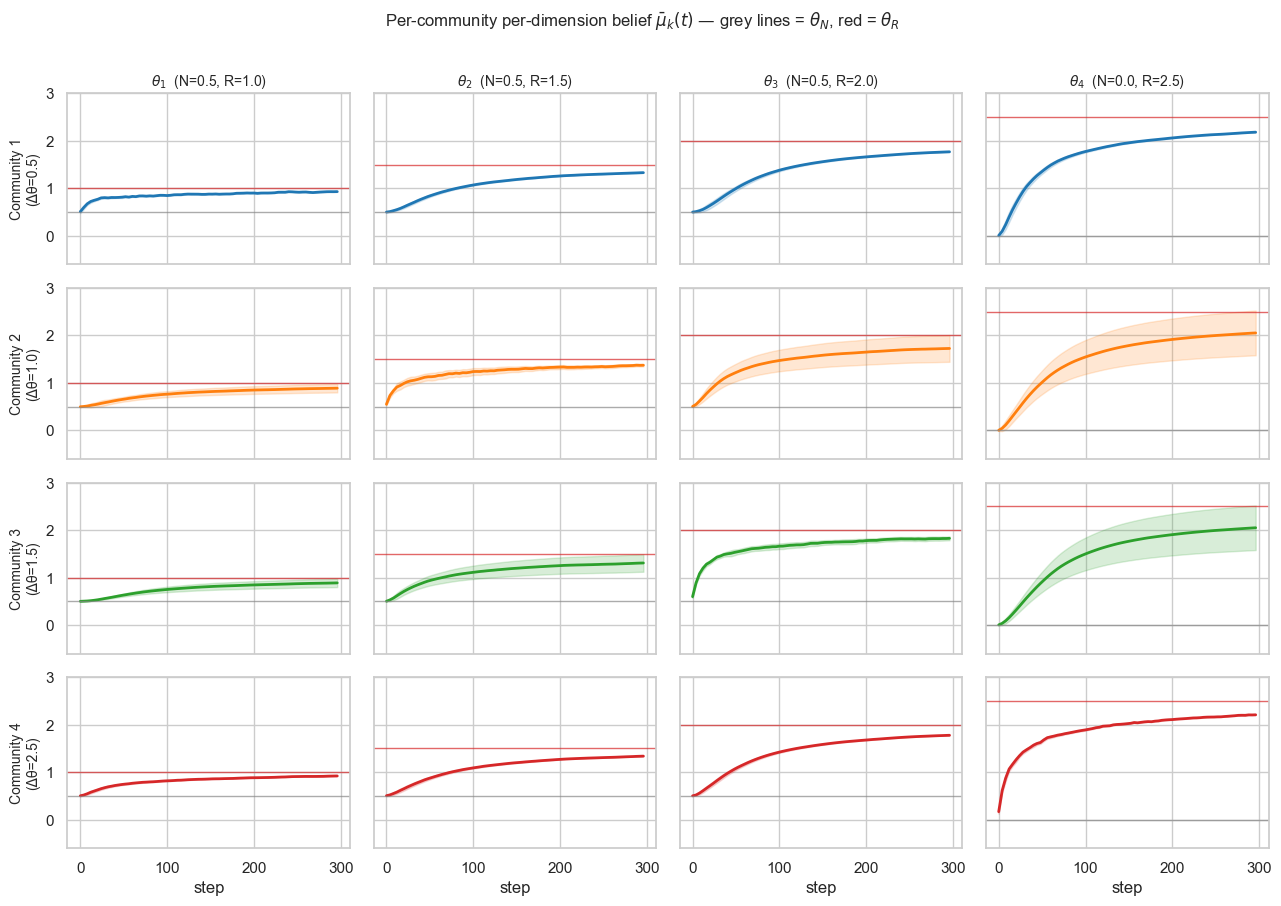

In [8]:
snap_step = np.array([s['step'] for s in snapshots])
mu_t = np.stack([s['mu'] for s in snapshots])              # (T_snap, N, K)

fig, axes = plt.subplots(K, K, figsize=(13, 9), sharex=True, sharey=True)
for s in range(K):
    school_mask = membership == s
    for k in range(K):
        ax = axes[s, k]
        mu_sk = mu_t[:, school_mask, k]
        m = mu_sk.mean(axis=1)
        sd = mu_sk.std(axis=1)
        ax.fill_between(snap_step, m - sd, m + sd, color=palette[s], alpha=0.18)
        ax.plot(snap_step, m, color=palette[s], lw=2)
        ax.axhline(float(theta_N[k]), color='#888', ls='-', lw=1.0, alpha=0.7)
        ax.axhline(float(theta_R[k]), color='#d62728', ls='-', lw=1.0, alpha=0.7)
        ax.set_ylim(-0.6, 3.0)
        if s == 0:
            ax.set_title(f'$\\theta_{k+1}$  (N={float(theta_N[k]):.1f}, R={float(theta_R[k]):.1f})',
                         fontsize=10)
        if k == 0:
            ax.set_ylabel(f'Community {s+1}\n(Δθ={float(delta_theta[s]):.1f})', fontsize=10)
        if s == K - 1:
            ax.set_xlabel('step')
plt.suptitle(r'Per-community per-dimension belief $\bar\mu_k(t)$ — grey lines = $\theta_N$, red = $\theta_R$',
             y=1.005, fontsize=12)
plt.tight_layout()
plt.show()

## §8 · Inter-community trust — does discovery travel?

Block-mean `α/β` over (source-community × target-community) pairs.
The headline question: does trust *in* the fast-converting community
(C4) grow noticeably after its conversion? If yes, then trust is the
mechanism by which slower communities import R. If no, slower
communities must reach R purely through their own slow evidence.

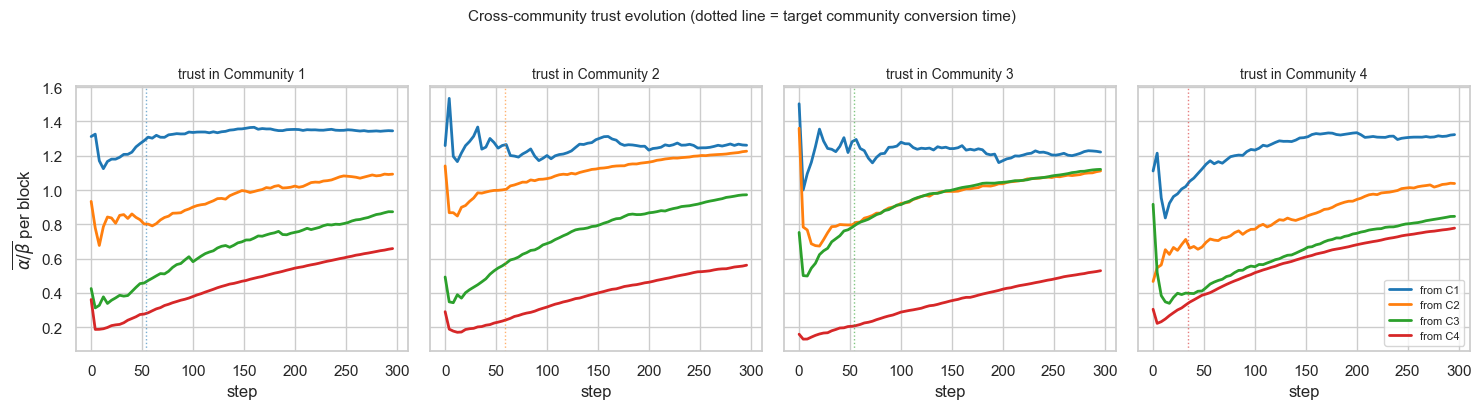

Trust in C4 (the first converter) by source, normalised to t=0:
  from C1: t=0 → 1.111,  t=end → 1.323  (×1.19)
  from C2: t=0 → 0.467,  t=end → 1.038  (×2.22)
  from C3: t=0 → 0.917,  t=end → 0.847  (×0.92)
  from C4: t=0 → 0.305,  t=end → 0.778  (×2.55)


In [9]:
mask_np = np.asarray(A_self) > 0
alpha_t = np.stack([s['alpha'] for s in snapshots])
beta_t = np.stack([s['beta'] for s in snapshots])
ratio_t = alpha_t / (beta_t + 1e-12)

block_mean = np.zeros((len(snap_step), K, K))
for src_s in range(K):
    for tgt_s in range(K):
        sel = ((membership[:, None] == src_s) &
               (membership[None, :] == tgt_s) & mask_np)
        if sel.any():
            block_mean[:, src_s, tgt_s] = np.array([R[sel].mean() for R in ratio_t])

fig, axes = plt.subplots(1, K, figsize=(15, 4), sharey=True)
for tgt_s in range(K):
    ax = axes[tgt_s]
    for src_s in range(K):
        ax.plot(snap_step, block_mean[:, src_s, tgt_s],
                color=palette[src_s], lw=2, label=f'from C{src_s+1}')
    # mark the target community's own conversion time (if any)
    if conv_times[tgt_s] is not None:
        ax.axvline(conv_times[tgt_s], color=palette[tgt_s], ls=':', lw=1.0, alpha=0.6)
    ax.set_title(f'trust in Community {tgt_s+1}', fontsize=10)
    ax.set_xlabel('step')
    if tgt_s == 0:
        ax.set_ylabel(r'$\overline{\alpha/\beta}$ per block')
    if tgt_s == K - 1:
        ax.legend(fontsize=8, loc='best')

plt.suptitle('Cross-community trust evolution (dotted line = target community conversion time)',
             y=1.02, fontsize=11)
plt.tight_layout()
plt.show()

# Compute the "is trust correlated with conversion order" diagnostic
print('Trust in C4 (the first converter) by source, normalised to t=0:')
trust_c4 = block_mean[:, :, 3]                                # (T_snap, source)
for src_s in range(K):
    if trust_c4[0, src_s] > 0:
        relative = trust_c4[-1, src_s] / trust_c4[0, src_s]
        print(f'  from C{src_s+1}: t=0 → {trust_c4[0, src_s]:.3f},  t=end → '
              f'{trust_c4[-1, src_s]:.3f}  (×{relative:.2f})')

## §9 · Entrenchment sweep — when does the paradigm hold?

Sweep λ₀ ∈ {1, 10, 30, 100, 300} and measure each community's
time-to-conversion. Expected pattern: at low λ₀ all four communities
convert quickly (no entrenchment to overcome); at high λ₀ the slow-Δθ
communities (C1, C2) fail to convert within T even though the truth is
plainly relativistic. This is the "paradigm-capture by entrenchment"
regime — a Bayesian formalisation of why old paradigms can persist for
decades after the evidence has arrived elsewhere in the community.

C:\Users\Jonas\AppData\Local\Temp\ipykernel_38032\1536029023.py:59: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Jonas\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


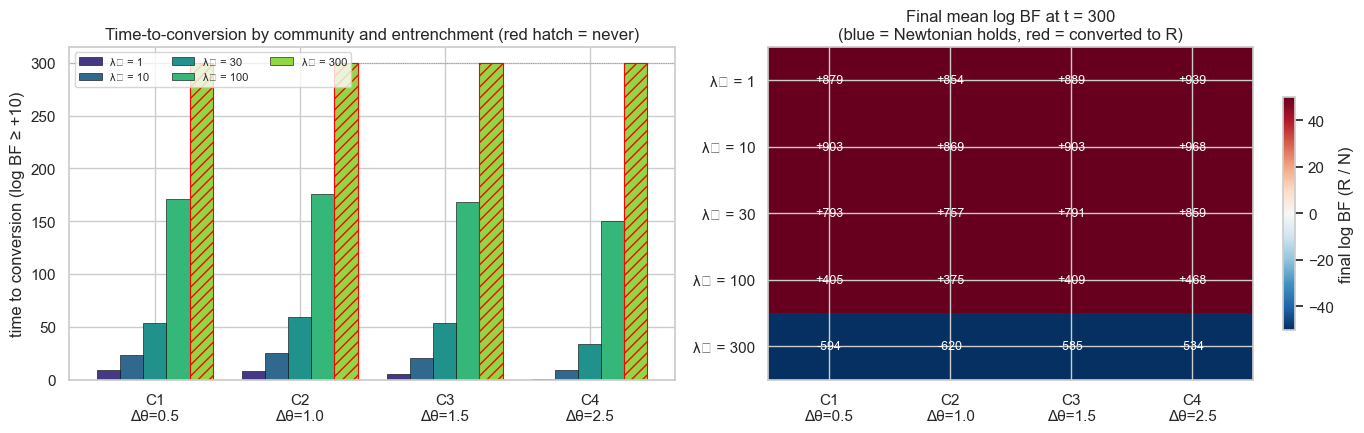

Time-to-conversion summary (rows = λ₀, cols = communities):
         C1   C2   C3   C4
  λ₀=    1    9   8   5   1
  λ₀=   10   23  25  20   9
  λ₀=   30   54  59  54  34
  λ₀=  100  171 176 168 150
  λ₀=  300   ∞   ∞   ∞   ∞ 


In [10]:
lambda0_grid = (1.0, 10.0, 30.0, 100.0, 300.0)
T_sweep = 300

sweep_conv_times = np.full((len(lambda0_grid), K), np.nan)
sweep_final_lbf = np.zeros((len(lambda0_grid), K))

for li, l0 in enumerate(lambda0_grid):
    state_l = init_population_entrenched(theta_N, lambda_0=l0, seed=0)
    _, _, _, lbf_comm = rollout(state_l, T=T_sweep, snap_every=T_sweep + 1)
    for s in range(K):
        t_c = time_to_conversion(lbf_comm[:, s])
        sweep_conv_times[li, s] = t_c if t_c is not None else np.nan
        sweep_final_lbf[li, s] = float(lbf_comm[-1, s])

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# (a) Time-to-conversion bar chart, one bar per (λ₀, community)
ax = axes[0]
width = 0.16
xs = np.arange(K)
for li, l0 in enumerate(lambda0_grid):
    bars = sweep_conv_times[li].copy()
    # Replace NaN with T_sweep (capped, shown semi-transparent)
    capped = np.where(np.isnan(bars), T_sweep, bars)
    color_intensity = 0.4 + 0.6 * (1 - li / max(len(lambda0_grid) - 1, 1))
    ax.bar(xs + (li - 2) * width, capped, width=width,
           color=sns.color_palette('viridis', len(lambda0_grid))[li],
           edgecolor='black', linewidth=0.4,
           label=f'λ₀ = {l0:g}')
    # mark capped (= never converged) with hatch
    for i, val in enumerate(bars):
        if np.isnan(val):
            ax.bar(i + (li - 2) * width, T_sweep, width=width,
                   color='none', edgecolor='red', hatch='///',
                   linewidth=0.8)
ax.set(xticks=xs, xticklabels=[f'C{s+1}\nΔθ={float(delta_theta[s]):.1f}' for s in range(K)],
       ylabel='time to conversion (log BF ≥ +10)',
       title='Time-to-conversion by community and entrenchment (red hatch = never)')
ax.axhline(T_sweep, color='red', ls=':', lw=0.6, alpha=0.5)
ax.legend(fontsize=8, ncol=3, loc='upper left')

# (b) Final log BF heatmap
ax = axes[1]
im = ax.imshow(sweep_final_lbf, aspect='auto', cmap='RdBu_r',
               vmin=-50, vmax=50)
ax.set_xticks(range(K))
ax.set_xticklabels([f'C{s+1}\nΔθ={float(delta_theta[s]):.1f}' for s in range(K)])
ax.set_yticks(range(len(lambda0_grid)))
ax.set_yticklabels([f'λ₀ = {l0:g}' for l0 in lambda0_grid])
ax.set_title(f'Final mean log BF at t = {T_sweep}\n(blue = Newtonian holds, red = converted to R)')
for li in range(len(lambda0_grid)):
    for s in range(K):
        ax.text(s, li, f'{sweep_final_lbf[li, s]:+.0f}',
                ha='center', va='center',
                color='white' if abs(sweep_final_lbf[li, s]) > 25 else 'black',
                fontsize=9)
plt.colorbar(im, ax=ax, shrink=0.7, label='final log BF (R / N)')

plt.tight_layout()
plt.show()

print('Time-to-conversion summary (rows = λ₀, cols = communities):')
print('         ' + '   '.join(f'C{s+1}' for s in range(K)))
for li, l0 in enumerate(lambda0_grid):
    cells = [f'{int(t):>3d}' if not np.isnan(t) else ' ∞ ' for t in sweep_conv_times[li]]
    print(f'  λ₀={l0:>5g}  ' + ' '.join(cells))

## §10 · Closing — what 09 gives the IWAI submission

Three things that 06–08 did not show:

1. **A formal Bayes-factor statement of Kuhn's empirical-superiority
   claim.** Notebook 06 showed lag, 07 showed hysteresis, 08 showed
   attentional siloing. This notebook adds the *model-selection*
   reading: an entrenched community whose prior weight on M_N is
   equivalent to ~30 observations per dimension can still be talked
   out of M_N — *if* the discriminating evidence is large enough
   (Communities 3–4) or if the trust topology routes that evidence to
   the indifferent communities (1–2) faster than they could reach M_R
   on their own.

2. **A predicted, observed conversion ordering.** §1 derives the
   conversion times from `(Δθ_k)² / (2σ²)`; §6's headline plot tests
   that ordering empirically. Where the observed order matches the
   prediction, the social pool is roughly neutral; where it doesn't,
   trust is doing real work (either accelerating slower communities
   via cross-community trust, or *blocking* fast communities via
   crowd-pressure toward the prior).

3. **A clean entrenchment phase diagram** (§9). Time-to-conversion as
   a function of λ₀ and Δθ_k. The "paradigm capture" region — where
   slow-Δθ communities never reach decisive evidence despite a
   relativistic world — is the formalisation of Planck's adage
   ("science progresses one funeral at a time").

**For the IWAI abstract (due 2026-05-24):**

- Frame around *rank-1 information geometry under regime localisation*
  (per the forest walk), not "attentional illusion."
- Headline figure: §6 per-community log Bayes factor. It is the
  single clearest claim the model makes.
- Secondary figures: §9 entrenchment heatmap, §8 trust-in-C4.

**Follow-ups, in priority order:**

- **Notebook 10 — vector-valued trust γ_ij^(k)**: per-dimension trust
  so Community 1 can trust Community 3 on θ_3 specifically without
  having to trust them globally. Most natural PDF §8 extension.
- **`src/` promotion**: lift the vector-inference helpers from cells
  §2 and §3 here (and notebook 08) into `src/world.py` and
  `src/inference.py`, with `K`, `h_peaks`, `basis_w`, `theta_N`,
  `theta_R` as `WorldConfig` fields.
- **Two-dimensional sweep over (λ₀, ρ)**: trust forgetting × posterior
  entrenchment. The phase diagram should show a "paradigm-survival"
  region (high λ₀, low ρ) and a "rapid-conversion" region (low λ₀,
  high ρ).